# Data Leakage Investigation — NEU-DET train/validation

The ResNet18 fine-tuned model reached 100% validation accuracy, which
is suspiciously perfect. This notebook checks whether the train and
validation splits contain near-duplicate images (a known issue with
some NEU-DET distributions, since many crops come from the same source
micrographs).

Method: perceptual hashing (pHash) — for every validation image, find
its closest match (by Hamming distance) among train images of the same
class. A distance of 0 means visually identical; small distances (<=5)
mean near-identical (e.g. a slightly shifted crop of the same region).

In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
from PIL import Image

from src.data.dataset import CLASS_NAMES
from src.utils.leakage_check import find_near_duplicates

DATA_ROOT = '../data/raw/NEU-DET'
TRAIN_IMAGES = f'{DATA_ROOT}/train/images'
VAL_IMAGES = f'{DATA_ROOT}/validation/images'

In [2]:
# This compares every validation image against every train image of the
# same class (~240 x 60 comparisons per class = fast, a few seconds total).
duplicates = find_near_duplicates(TRAIN_IMAGES, VAL_IMAGES, CLASS_NAMES, max_distance=5)

print(f'Found {len(duplicates)} near-duplicate pairs (Hamming distance <= 5) out of 360 validation images.')
print()
for d in duplicates[:10]:
    val_name = d['val_file'].split('/')[-1]
    train_name = d['train_file'].split('/')[-1]
    print(f"[{d['class']:<16}] distance={d['distance']:<3} val={val_name:<20} train={train_name}")

Found 50 near-duplicate pairs (Hamming distance <= 5) out of 360 validation images.

[inclusion       ] distance=0   val=..\data\raw\NEU-DET\validation\images\inclusion\inclusion_241.jpg train=..\data\raw\NEU-DET\train\images\inclusion\inclusion_229.jpg
[inclusion       ] distance=0   val=..\data\raw\NEU-DET\validation\images\inclusion\inclusion_249.jpg train=..\data\raw\NEU-DET\train\images\inclusion\inclusion_229.jpg
[inclusion       ] distance=0   val=..\data\raw\NEU-DET\validation\images\inclusion\inclusion_250.jpg train=..\data\raw\NEU-DET\train\images\inclusion\inclusion_229.jpg
[inclusion       ] distance=0   val=..\data\raw\NEU-DET\validation\images\inclusion\inclusion_257.jpg train=..\data\raw\NEU-DET\train\images\inclusion\inclusion_229.jpg
[pitted_surface  ] distance=0   val=..\data\raw\NEU-DET\validation\images\pitted_surface\pitted_surface_252.jpg train=..\data\raw\NEU-DET\train\images\pitted_surface\pitted_surface_107.jpg
[pitted_surface  ] distance=0   val=..\data\raw\NE

In [3]:
# Distribution of best-match distances per class
from collections import Counter

class_counts = Counter(d['class'] for d in duplicates)
print('Near-duplicates found per class (out of 60 val images each):')
for c in CLASS_NAMES:
    print(f'  {c:<16}: {class_counts.get(c, 0)}')

Near-duplicates found per class (out of 60 val images each):
  crazing         : 6
  inclusion       : 26
  patches         : 0
  pitted_surface  : 16
  rolled-in_scale : 0
  scratches       : 2


## Visual check — inspect the closest (most suspicious) pairs

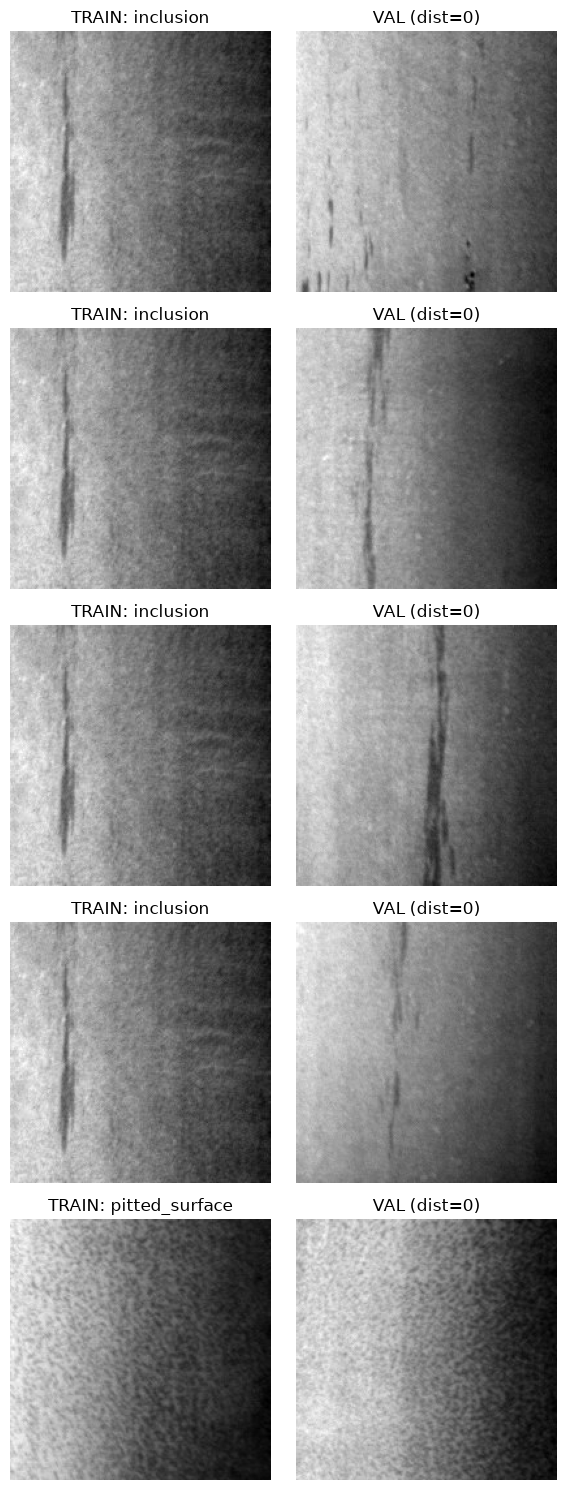

In [4]:
n_show = min(5, len(duplicates))
fig, axes = plt.subplots(n_show, 2, figsize=(6, 3 * n_show))
if n_show == 1:
    axes = [axes]

for i in range(n_show):
    d = duplicates[i]
    train_img = Image.open(d['train_file']).convert('L')
    val_img = Image.open(d['val_file']).convert('L')

    axes[i][0].imshow(train_img, cmap='gray')
    axes[i][0].set_title(f"TRAIN: {d['class']}")
    axes[i][0].axis('off')

    axes[i][1].imshow(val_img, cmap='gray')
    axes[i][1].set_title(f"VAL (dist={d['distance']})")
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()

## Interpreting the result

- **If most/all validation images have a distance-0 or near-0 match in
  train**: this confirms train/validation leakage — the 100% ResNet18
  accuracy is explained by the model having effectively seen
  near-identical images during training. This should be documented in
  the README as a known dataset characteristic, not treated as a real
  99-100% capability.
- **If only a handful of images match closely**: the split is mostly
  clean, and the high accuracy may be a genuine reflection of how
  visually distinct these 6 defect classes are in this dataset (still
  worth noting as a dataset limitation — real production data would be
  noisier).